In [1]:
import numpy as np
import astropy.constants as const
from pyuvdata import UVData, UVFlag

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

filename="/Users/bryna/Projects/Physics/data_files/lwa_beam_testing/20260112_120008-120018_34MHz_casa_05h_calibrated.uvfits"

In [2]:
uvd = UVData.from_file(filename)

In [3]:
grid_uvw_freq_pol = np.zeros((uvd.Nblts, uvd.Nfreqs, uvd.Npols, 3), dtype=float)
grid_uvw_mask = np.zeros((uvd.Nblts, uvd.Nfreqs, uvd.Npols, 3), dtype=bool)

In [4]:
grid_uvw_freq_pol.shape

(124256, 542, 2, 3)

In [5]:
for pi, pol in enumerate(uvd.polarization_array):
    for fi, freq in enumerate(uvd.freq_array):
        grid_uvw_freq_pol[:, fi, pi, :] = (uvd.uvw_array * freq / const.c)
        grid_uvw_mask[:, fi, pi, :] = np.tile(uvd.flag_array[:, fi, pi], (3,1)).T

In [6]:
grid_uvw_freq_pol = np.ma.masked_array(grid_uvw_freq_pol, mask=grid_uvw_mask)

In [7]:
print(grid_uvw_freq_pol[:,:,:,0].max())
print(grid_uvw_freq_pol[:,:,:,0].min())
print(grid_uvw_freq_pol[:,:,:,1].max())
print(grid_uvw_freq_pol[:,:,:,1].min())


198.08863975789848
-195.06058758667066
227.10100206602135
-209.78353705114472


In [8]:
max_uv = 250
min_uv = -1 * max_uv
nbins = (max_uv - min_uv) * 2 + 1
uv_edges, steps = np.linspace(min_uv,max_uv,nbins, retstep=True)
print(steps)
print(uv_edges.min())
print(uv_edges.max())

0.5
-250.0
250.0


In [9]:
xx_uv_hist, _, _ = np.histogram2d(
    grid_uvw_freq_pol[:,:,0,0].compressed(),
    grid_uvw_freq_pol[:,:,0,1].compressed(),
    bins=(uv_edges, uv_edges)
)
xx_uv_hist = xx_uv_hist.T

In [10]:
yy_uv_hist, _, _ = np.histogram2d(
    grid_uvw_freq_pol[:,:,1,0].compressed(),
    grid_uvw_freq_pol[:,:,1,1].compressed(),
    bins=(uv_edges, uv_edges)
)
yy_uv_hist = yy_uv_hist.T

In [11]:
print(xx_uv_hist.min())
print(xx_uv_hist.max())
print(yy_uv_hist.min())
print(yy_uv_hist.max())



0.0
299212.0
0.0
267776.0


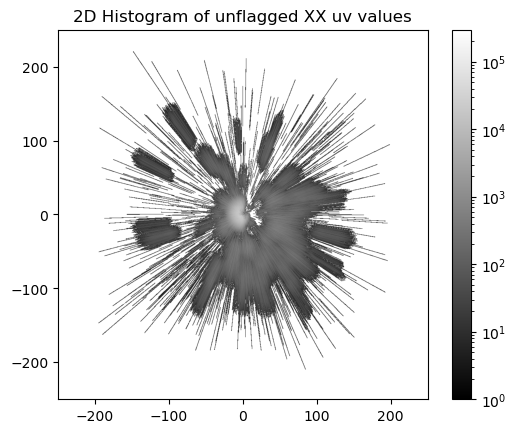

In [12]:
fig, ax = plt.subplots()
pl = ax.imshow(
    xx_uv_hist,
    origin='lower',
    extent=[uv_edges[0], uv_edges[-1], uv_edges[0], uv_edges[-1]],
    cmap="gist_gray",
    norm=LogNorm()
)
ax.set_title("2D Histogram of unflagged XX uv values")
fig.colorbar(pl, ax=ax)

plt.show()


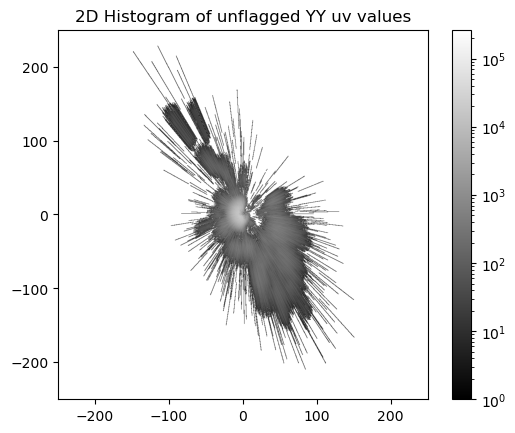

In [13]:
fig, ax = plt.subplots()
pl = ax.imshow(
    yy_uv_hist,
    origin='lower',
    extent=[uv_edges[0], uv_edges[-1], uv_edges[0], uv_edges[-1]],
    cmap="gist_gray",
    norm=LogNorm()
)
ax.set_title("2D Histogram of unflagged YY uv values")
fig.colorbar(pl, ax=ax)

plt.show()

In [37]:
uvf = UVFlag(uvd, copy_flags=True)

In [38]:
print(uvf.flag_array.min())
print(uvf.flag_array.max())

False
True


In [39]:
uvf.to_metric()
print(uvf.metric_array.min())
print(uvf.metric_array.max())

0.0
1.0


In [40]:
uvf.to_waterfall()

In [41]:
print(uvf.metric_array.min())
print(uvf.metric_array.max())

0.6284446665730526
0.881289251193894


In [42]:
uvf.metric_array.shape

(2, 542, 2)

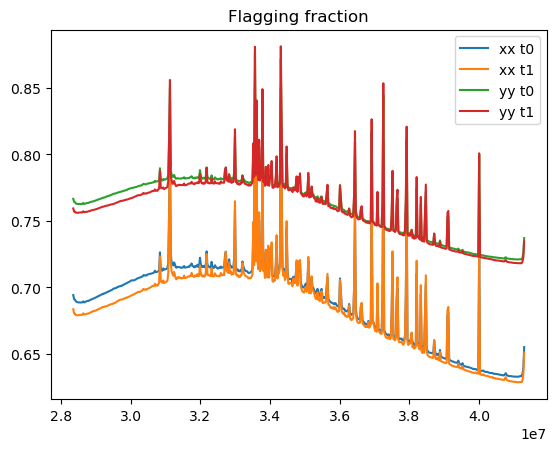

In [47]:
fig, ax = plt.subplots()
pl = ax.plot(
    uvf.freq_array,
    uvf.metric_array[0,:, 0],
    label="xx t0",
)
pl = ax.plot(
    uvf.freq_array,
    uvf.metric_array[1,:, 0],
    label="xx t1",
)
pl = ax.plot(
    uvf.freq_array,
    uvf.metric_array[0,:, 1],
    label="yy t0",
)
pl = ax.plot(
    uvf.freq_array,
    uvf.metric_array[1,:, 1],
    label="yy t1",
)
ax.set_title("Flagging fraction")
plt.legend()
plt.show()